In [40]:
from datatools import get_price, get_basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.signal import argrelextrema

In [28]:
df = get_price(codes = ['300274.SZ'], start_date='2011-11-02', end_date='2025-12-31', fields=['close'], fq='post')

In [30]:
# 找局部高点（order=60 表示前后60个交易日内最高）
# order值越大，高点越显著（越稀疏）；越小，高点越多（包含小波峰）
high_idx = argrelextrema(df['close'].values, np.greater_equal, order=60)[0]
highs = df.iloc[high_idx]

In [ ]:
# 计算相邻高点间隔
highs['prev_date'] = highs['trade_date'].shift(1)
highs['interval_days'] = (highs['trade_date'] - highs['prev_date']).dt.days
highs['interval_years'] = highs['interval_days'] / 255

In [36]:
highs

,ts_code,trade_date,close,prev_date,interval_days,interval_years
540,300274.SZ,2014-02-10,73.24440,2011-11-25,808.0,3.168627
683,300274.SZ,2014-09-04,72.68446,2014-02-10,206.0,0.807843
851,300274.SZ,2015-06-03,187.28960,2014-09-04,272.0,1.066667
963,300274.SZ,2015-11-25,115.63584,2015-06-03,175.0,0.686275
1109,300274.SZ,2016-07-07,93.43200,2015-11-25,225.0,0.882353
1438,300274.SZ,2017-11-13,144.56969,2016-07-07,494.0,1.937255
1787,300274.SZ,2019-04-19,88.55984,2017-11-13,522.0,2.047059
1879,300274.SZ,2019-09-02,86.83389,2019-04-19,136.0,0.533333
1990,300274.SZ,2020-02-21,92.76575,2019-09-02,172.0,0.674510
2230,300274.SZ,2021-02-10,806.71566,2020-02-21,355.0,1.392157


In [33]:
mean_interval = highs['interval_years'].mean()
median_interval = highs['interval_years'].median()

=== 显著高点验证结果（局部峰值，非历史新高） ===
总共识别出 16 个显著高点
平均间隔：1.25 年
中位数间隔：1.04 年
间隔标准差：0.67 年

各次高点间隔（年）：
     trade_date    close  interval_years
540  2014-02-10    73.24            3.17
683  2014-09-04    72.68            0.81
851  2015-06-03   187.29            1.07
963  2015-11-25   115.64            0.69
1109 2016-07-07    93.43            0.88
1438 2017-11-13   144.57            1.94
1787 2019-04-19    88.56            2.05
1879 2019-09-02    86.83            0.53
1990 2020-02-21    92.77            0.67
2230 2021-02-10   806.72            1.39
2398 2021-10-27  1170.51            1.02
2600 2022-08-23   982.79            1.18
2806 2023-07-03   835.71            1.23
2973 2024-03-11   743.01            0.99
3111 2024-10-08  1143.87            0.83
3375 2025-11-06  2017.71            1.55


C:\Users\User\AppData\Local\Temp\ipykernel_26500\3293300866.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(highs[['trade_date', 'close', 'interval_years']].round(2))


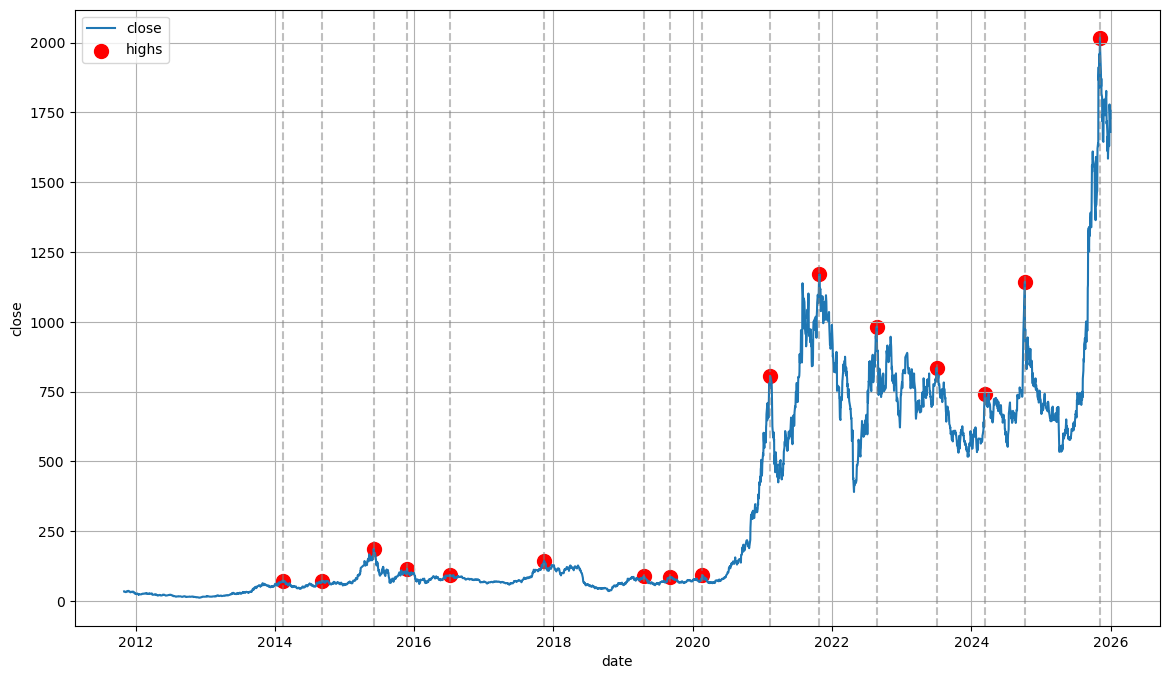

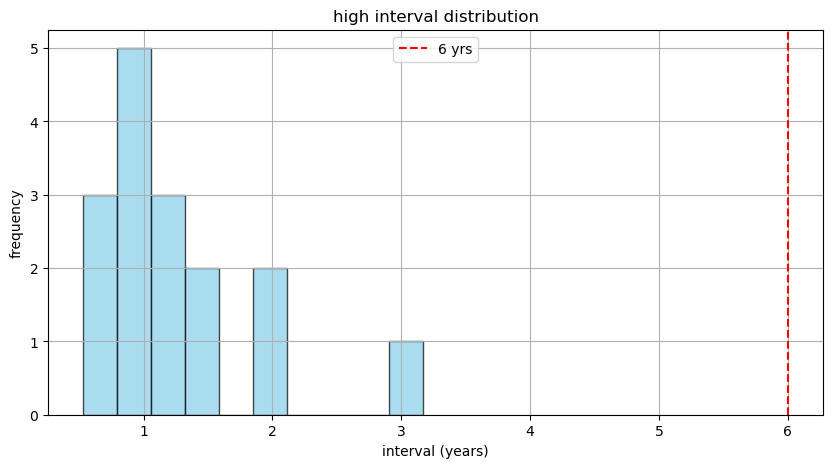

In [39]:
# 统计
print("=== 显著高点验证结果（局部峰值，非历史新高） ===")
print(f"总共识别出 {len(highs)} 个显著高点")
print(f"平均间隔：{mean_interval:.2f} 年")
print(f"中位数间隔：{median_interval:.2f} 年")
print(f"间隔标准差：{highs['interval_years'].std():.2f} 年")
print("\n各次高点间隔（年）：")
print(highs[['trade_date', 'close', 'interval_years']].round(2))

# 可视化
plt.figure(figsize=(14, 8))
plt.plot(df['trade_date'], df['close'], label='close', linewidth=1.5)
plt.scatter(highs['trade_date'], highs['close'], color='red', s=100, label='highs')

# 画6年周期参考线
for i in range(len(highs)):
    plt.axvline(highs['trade_date'].iloc[i], color='gray', linestyle='--', alpha=0.5)


plt.xlabel('date')
plt.ylabel('close')
plt.legend()
plt.grid(True)
plt.show()

# 间隔分布直方图
plt.figure(figsize=(10, 5))
plt.hist(highs['interval_years'], bins=10, alpha=0.7, color='skyblue', edgecolor='black')
plt.axvline(6, color='red', linestyle='--', label='6 yrs')
plt.title('high interval distribution')
plt.xlabel('interval (years)')
plt.ylabel('frequency')
plt.legend()
plt.grid(True)
plt.show()